# 04 — Evaluación generativa (t-SNE, marginales, clasificador)

Evalúa ventanas sintéticas de las **3 seeds** (42, 123, 2026):

- **Agregado** — pool completo vs `donor_validation` / `donor_train`
- **Por semilla** — MMD, marginales, AUC del clasificador por seed (detectar outliers)

**No usar NVDA visible/test para tunear la GAN.**

In [1]:
from pathlib import Path
import importlib
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import src.data as _data_module
import src.metrics as _metrics_module
import src.paths as _paths_module
import src.synthetic_io as _synthetic_io_module

for _module in (_data_module, _metrics_module, _paths_module, _synthetic_io_module):
    importlib.reload(_module)

from src.data import CHANNELS, load_donor_windows, load_nvda_hidden_windows, windows_to_array
from src.metrics import channel_summary, per_seed_mmd_summary, temporal_autocorr_report
from src.paths import default_windows_dir, outputs_dir
from src.synthetic_io import load_synthetic_parquets, official_seeds, split_synthetic_by_seed

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
RNG = np.random.default_rng(42)

I0000 00:00:1788109413.962648  824018 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788109413.963086  824018 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788109414.001282  824018 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788109414.923261  824018 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

In [2]:
TSNE_PERPLEXITY = 30
TSNE_SAMPLES_PER_GROUP = 400
CV_FOLDS = 5

synthetic, synthetic_paths = load_synthetic_parquets(seeds=official_seeds())
synthetic_by_seed = split_synthetic_by_seed(synthetic)
validation = load_donor_windows("donor_validation", windows_dir=default_windows_dir())
train = load_donor_windows("donor_train", windows_dir=default_windows_dir())
nvda_hidden = load_nvda_hidden_windows(windows_dir=default_windows_dir())

X_syn = windows_to_array(synthetic)
X_val = windows_to_array(validation)
X_train = windows_to_array(train)
X_nvda_hidden = windows_to_array(nvda_hidden)
X_syn_by_seed = {seed: windows_to_array(frame) for seed, frame in synthetic_by_seed.items()}

print("Parquets sintéticos:")
for path in synthetic_paths:
    print(f"  - {path.name}")
print(f"Sintético total: {len(X_syn)} ventanas")
for seed in sorted(X_syn_by_seed):
    print(f"  seed {seed}: {len(X_syn_by_seed[seed])} ventanas")
print(f"Validation (donors ocultos): {len(X_val)}")
print(f"Train (donors): {len(X_train)}")
print(f"NVDA hidden (exploratorio): {len(X_nvda_hidden)}")

Parquets sintéticos:
  - synthetic_seed42_n5000.parquet
  - synthetic_seed123_n5000.parquet
  - synthetic_seed2026_n5000.parquet
Sintético total: 15000 ventanas
  seed 42: 5000 ventanas
  seed 123: 5000 ventanas
  seed 2026: 5000 ventanas
Validation (ocultos): 380
Train (donors): 4910


## 1. Marginales — agregado (3 seeds) y por semilla

Comparamos histogramas/KDE de cada canal (todos los timesteps apilados) y estadísticas resumidas.

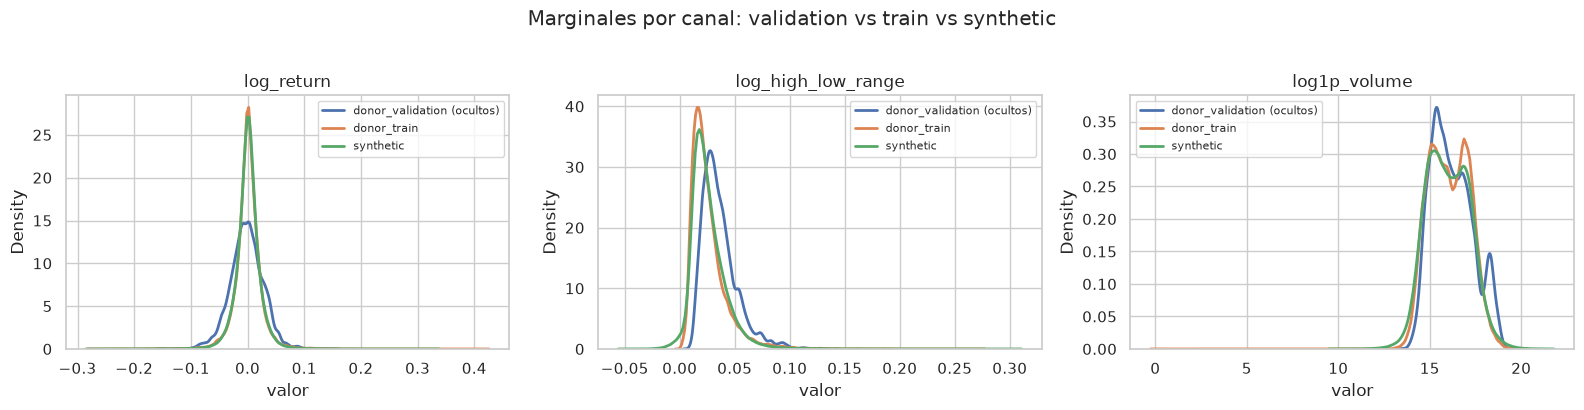

In [3]:
def flatten_channel(windows: np.ndarray, channel_idx: int) -> np.ndarray:
    return windows[:, :, channel_idx].reshape(-1)


sources = {
    "donor_validation (ocultos)": X_val,
    "donor_train": X_train,
    "synthetic": X_syn,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, ch_idx, name in zip(axes, range(3), CHANNELS):
    for label, arr in sources.items():
        values = flatten_channel(arr, ch_idx)
        sns.kdeplot(values, ax=ax, label=label, linewidth=2)
    ax.set_title(name)
    ax.set_xlabel("valor")
    ax.legend(fontsize=8)
plt.suptitle("Marginales por canal: validation vs train vs synthetic", y=1.02)
plt.tight_layout()

In [4]:
summary_rows = []
for label, arr in sources.items():
    stats = channel_summary(arr)
    stats.insert(0, "source", label)
    summary_rows.append(stats)
summary_table = pd.concat(summary_rows, ignore_index=True)
display(summary_table)

autocorr_rows = []
for label, arr in sources.items():
    ac = temporal_autocorr_report(arr)
    ac.insert(0, "source", label)
    autocorr_rows.append(ac)
autocorr_table = pd.concat(autocorr_rows, ignore_index=True)
print("Autocorrelación lag-1 (dependencia temporal):")
display(autocorr_table)

,source,channel,mean,std,min,max
0,donor_validation (ocultos),log_return,-0.001630,0.029279,-0.149299,0.149978
1,donor_validation (ocultos),log_high_low_range,0.036210,0.015943,0.009586,0.128724
2,donor_validation (ocultos),log1p_volume,16.219625,1.115950,13.508171,19.233361
3,donor_train,log_return,0.000811,0.023516,-0.277456,0.420617
4,donor_train,log_high_low_range,0.026026,0.016724,0.000000,0.273457
5,donor_train,log1p_volume,16.060272,1.093325,0.000000,20.143947
6,synthetic,log_return,0.000932,0.021505,-0.281074,0.333679
7,synthetic,log_high_low_range,0.025876,0.015834,-0.052881,0.307610
8,synthetic,log1p_volume,15.997133,1.170618,9.696812,21.558232


Autocorrelación lag-1 (dependencia temporal):


,source,channel,autocorr_lag1_mean,autocorr_lag1_std
0,donor_validation (ocultos),log_return,-0.058412,0.099225
1,donor_validation (ocultos),log_high_low_range,0.072556,0.096640
2,donor_validation (ocultos),log1p_volume,0.362559,0.152487
3,donor_train,log_return,-0.042547,0.145960
4,donor_train,log_high_low_range,0.252291,0.175862
5,donor_train,log1p_volume,0.462904,0.143563
6,synthetic,log_return,-0.049168,0.137378
7,synthetic,log_high_low_range,0.265647,0.171302
8,synthetic,log1p_volume,0.397672,0.179094


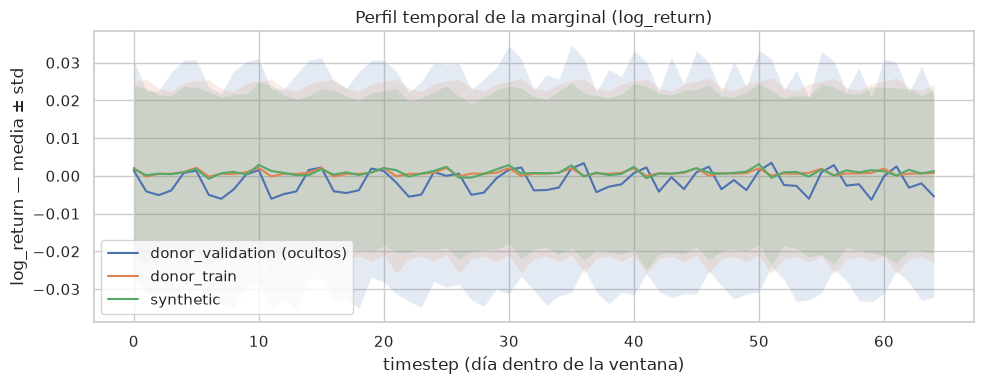

In [5]:
# Marginal por timestep (media en cada día t) — canal log_return
ch_idx = 0
fig, ax = plt.subplots(figsize=(10, 4))
for label, arr in sources.items():
    mean_t = arr[:, :, ch_idx].mean(axis=0)
    std_t = arr[:, :, ch_idx].std(axis=0)
    t = np.arange(arr.shape[1])
    ax.plot(t, mean_t, label=label)
    ax.fill_between(t, mean_t - std_t, mean_t + std_t, alpha=0.15)
ax.set_xlabel("timestep (día dentro de la ventana)")
ax.set_ylabel(f"{CHANNELS[ch_idx]} — media ± std")
ax.set_title("Perfil temporal de la marginal (log_return)")
ax.legend()
plt.tight_layout()

### 1b. Por semilla — MMD y marginales

Compara cada seed frente a `donor_validation` para detectar outliers (mejor/peor que el resto).

,seed,n_synthetic,mmd_flat
0,42,5000,0.022414
1,123,5000,0.014741
2,2026,5000,0.009423


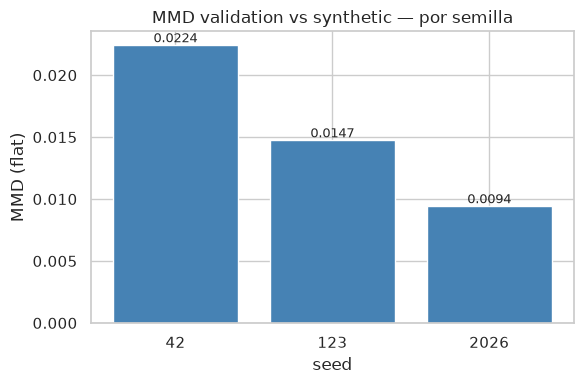

In [6]:
per_seed_mmd = per_seed_mmd_summary(validation, synthetic)
display(per_seed_mmd.sort_values("seed"))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(per_seed_mmd["seed"].astype(str), per_seed_mmd["mmd_flat"], color="steelblue")
ax.set_xlabel("seed")
ax.set_ylabel("MMD (flat)")
ax.set_title("MMD validation vs synthetic — por semilla")
for bar, value in zip(bars, per_seed_mmd["mmd_flat"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()

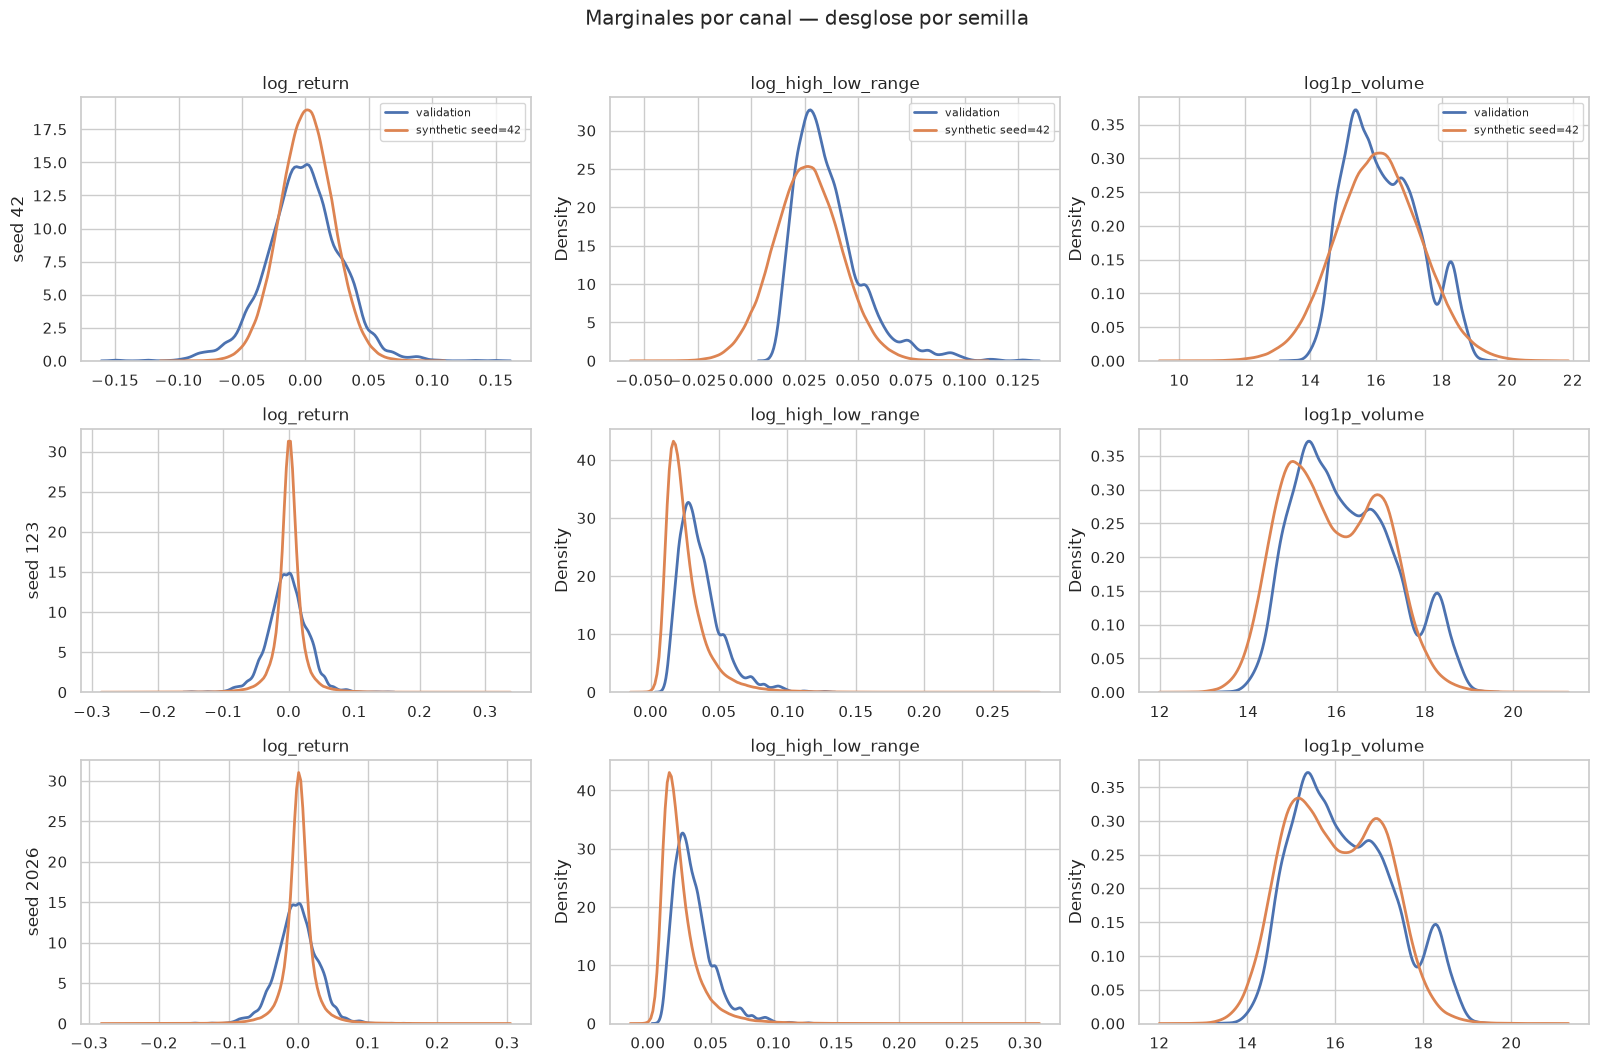

In [7]:
seeds = sorted(X_syn_by_seed)
fig, axes = plt.subplots(len(seeds), 3, figsize=(16, 3.5 * len(seeds)))
if len(seeds) == 1:
    axes = np.array([axes])

for row, seed in enumerate(seeds):
    X_seed = X_syn_by_seed[seed]
    for col, name in enumerate(CHANNELS):
        ax = axes[row, col]
        sns.kdeplot(flatten_channel(X_val, col), ax=ax, label="validation", linewidth=2)
        sns.kdeplot(flatten_channel(X_seed, col), ax=ax, label=f"synthetic seed={seed}", linewidth=2)
        ax.set_title(name)
        if col == 0:
            ax.set_ylabel(f"seed {seed}")
        if row == 0:
            ax.legend(fontsize=8)

plt.suptitle("Marginales por canal — desglose por semilla", y=1.01)
plt.tight_layout()

### 1c. PCA sobre los 3 canales (sintéticos desnormalizados)

PCA con una fila por `(ventana, día)` y 3 columnas (canales). Tras escalar, los **loadings** y **shares** (PC1–PC3) indican qué canal pesa más en cada componente.

Datos: `outputs/` por semilla, ya desnormalizados.


=== PCA canales | seed 42 | observaciones=325,000 ===
Varianza explicada: PC1=42.4%, PC2=33.4%, PC3=24.2%

Loadings:


,PC1,PC2,PC3
log_return,-0.033556,0.997875,0.055844
log_high_low_range,0.707373,-0.015760,0.706665
log1p_volume,0.706043,0.063216,-0.705341


Share en cada PC (squared loading normalizado):


,PC1_share,PC2_share,PC3_share
log_return,0.001126,0.995755,0.003119
log_high_low_range,0.500377,0.000248,0.499375
log1p_volume,0.498497,0.003996,0.497507


Mayor significancia en PC1: log_high_low_range (50.0%)
Mayor significancia en PC2: log_return (99.6%)
Mayor significancia en PC3: log_high_low_range (49.9%)

=== PCA canales | seed 123 | observaciones=325,000 ===
Varianza explicada: PC1=46.1%, PC2=33.3%, PC3=20.5%

Loadings:


...

Mayor significancia en PC1: log_high_low_range (50.0%)
Mayor significancia en PC2: log_return (99.3%)
Mayor significancia en PC3: log_high_low_range (49.9%)

=== PCA canales | agregado 3 seeds | observaciones=975,000 ===
Varianza explicada: PC1=44.8%, PC2=33.4%, PC3=21.9%

Loadings:


,PC1,PC2,PC3
log_return,-0.039235,0.997569,0.057586
log_high_low_range,0.707363,-0.012976,0.706731
log1p_volume,0.705760,0.068462,-0.705135


Share en cada PC (squared loading normalizado):


,PC1_share,PC2_share,PC3_share
log_return,0.001539,0.995145,0.003316
log_high_low_range,0.500363,0.000168,0.499469
log1p_volume,0.498098,0.004687,0.497215


Mayor significancia en PC1: log_high_low_range (50.0%)
Mayor significancia en PC2: log_return (99.5%)
Mayor significancia en PC3: log_high_low_range (49.9%)


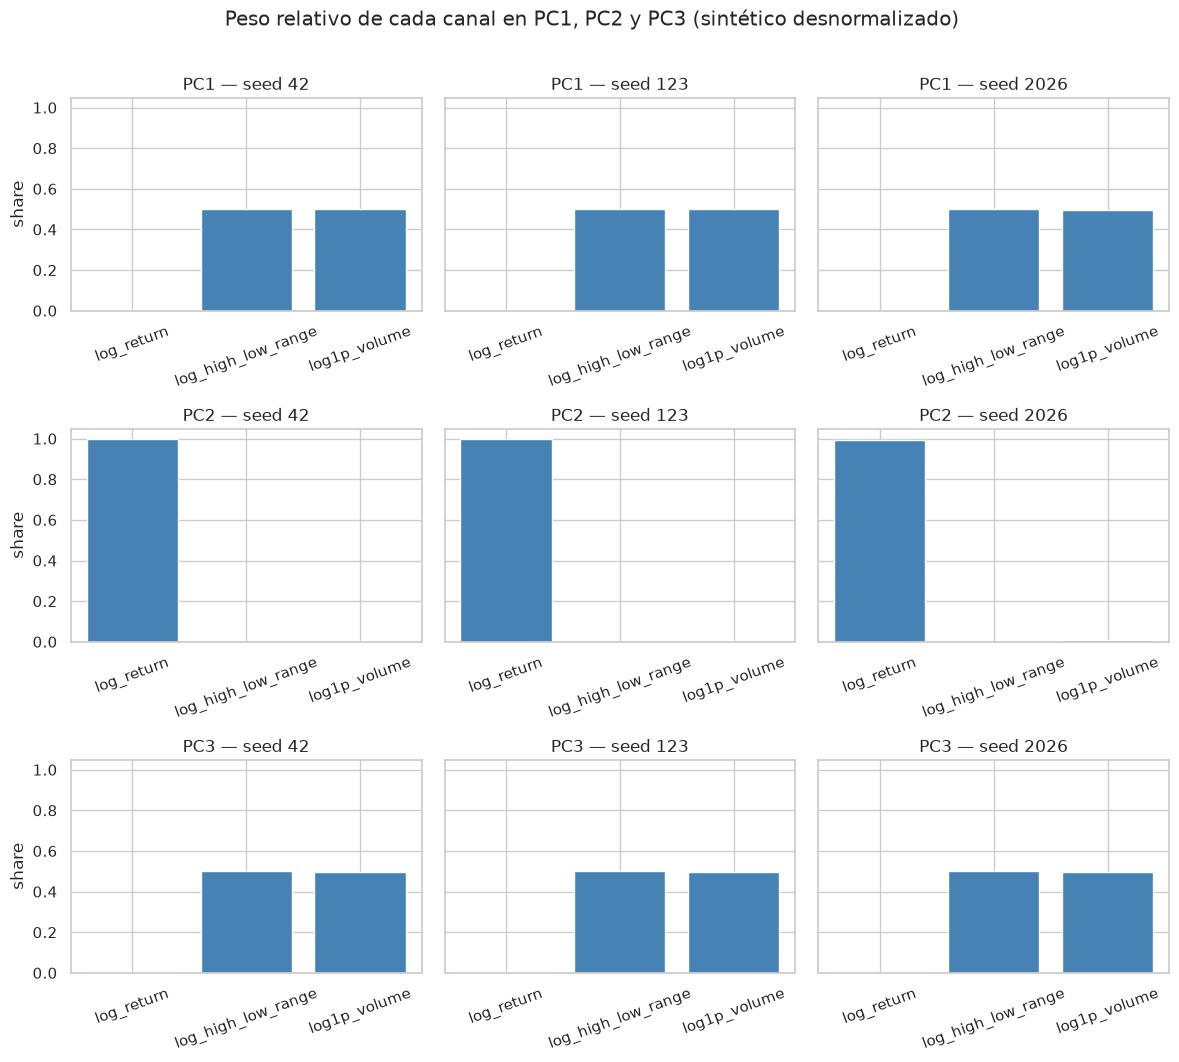

In [18]:
def windows_to_channel_matrix(windows: np.ndarray) -> np.ndarray:
    """(N, 65, 3) -> (N*65, 3) una fila por timestep con los 3 canales."""
    return windows.reshape(-1, windows.shape[-1])


def pca_channel_significance(windows: np.ndarray, label: str) -> pd.DataFrame:
    X = windows_to_channel_matrix(windows)
    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA(n_components=3, random_state=42)
    pca.fit(X_scaled)

    loadings = pd.DataFrame(
        pca.components_.T,
        index=CHANNELS,
        columns=[f"PC{i+1}" for i in range(3)],
    )

    sq = loadings.pow(2).div(loadings.pow(2).sum(axis=0), axis=1)
    loadings = loadings.join(sq.add_suffix("_share"))

    explained = pca.explained_variance_ratio_
    print(f"\n=== PCA canales | {label} | observaciones={len(X):,} ===")
    print(
        "Varianza explicada:",
        ", ".join(f"PC{i+1}={explained[i]:.1%}" for i in range(3)),
    )
    print("\nLoadings:")
    display(loadings[[f"PC{i+1}" for i in range(3)]])
    print("Share en cada PC (squared loading normalizado):")
    display(loadings[[f"PC{i+1}_share" for i in range(3)]])

    for i in range(3):
        pc = f"PC{i+1}"
        dominant = loadings[f"{pc}_share"].idxmax()
        print(
            f"Mayor significancia en {pc}: {dominant} "
            f"({loadings.loc[dominant, f'{pc}_share']:.1%})"
        )
    loadings.insert(0, "label", label)
    return loadings


pca_loadings_list = []
for seed in sorted(X_syn_by_seed):
    pca_loadings_list.append(pca_channel_significance(X_syn_by_seed[seed], f"seed {seed}"))
pca_loadings_list.append(pca_channel_significance(X_syn, "agregado 3 seeds"))
pca_loadings_all = pd.concat(pca_loadings_list)

seeds = sorted(X_syn_by_seed)
pc_names = [f"PC{i+1}" for i in range(3)]
fig, axes = plt.subplots(
    len(pc_names),
    len(seeds),
    figsize=(4 * len(seeds), 3.5 * len(pc_names)),
    sharey=True,
)
if len(seeds) == 1:
    axes = axes.reshape(-1, 1)

for col, seed in enumerate(seeds):
    block = pca_loadings_all.loc[pca_loadings_all["label"] == f"seed {seed}"]
    for row, pc in enumerate(pc_names):
        ax = axes[row, col]
        share_col = f"{pc}_share"
        ax.bar(CHANNELS, block[share_col].values, color="steelblue")
        ax.set_title(f"{pc} — seed {seed}")
        ax.tick_params(axis="x", rotation=20)
        if col == 0:
            ax.set_ylabel("share")
        if row == 0:
            ax.set_xlabel("")

plt.suptitle(
    "Peso relativo de cada canal en PC1, PC2 y PC3 (sintético desnormalizado)",
    y=1.01,
)
plt.tight_layout()

## 2. t-SNE — visualización de mezcla en el espacio de ventanas

Ventanas aplanadas (195 dims) → PCA (50) → t-SNE (2D). Submuestreo equilibrado por grupo.

In [9]:
def subsample_windows(windows: np.ndarray, n: int, rng: np.random.Generator) -> np.ndarray:
    n = min(n, len(windows))
    idx = rng.choice(len(windows), size=n, replace=False)
    return windows[idx]


def prepare_embedding_sets(
    groups: dict[str, np.ndarray],
    n_per_group: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    arrays = []
    labels = []
    for name, windows in groups.items():
        sample = subsample_windows(windows, n_per_group, rng)
        arrays.append(sample.reshape(len(sample), -1))
        labels.extend([name] * len(sample))
    return np.vstack(arrays), np.asarray(labels)


embed_groups = {
    "donor_validation": X_val,
    "donor_train": X_train,
    "synthetic": X_syn,
}
X_embed, y_embed = prepare_embedding_sets(embed_groups, TSNE_SAMPLES_PER_GROUP, RNG)
print(X_embed.shape, np.unique(y_embed, return_counts=True))

(1180, 195) (array(['donor_train', 'donor_validation', 'synthetic'], dtype='<U16'), array([400, 380, 400]))


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_embed)

pca = PCA(n_components=min(50, X_scaled.shape[1]), random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Varianza explicada PCA (50 comp): {pca.explained_variance_ratio_.sum():.2%}")

perplexity = min(TSNE_PERPLEXITY, max(5, len(X_pca) // 10))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=42,
)
X_tsne = tsne.fit_transform(X_pca)

embed_df = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "source": y_embed,
})

Varianza explicada PCA (50 comp): 79.02%


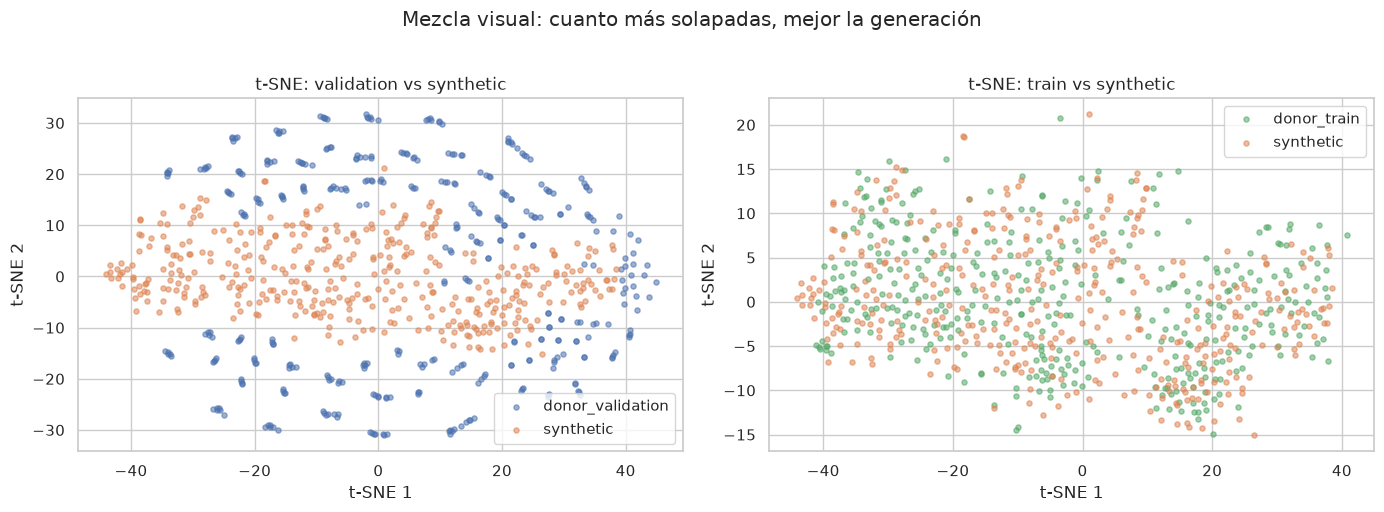

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {
    "donor_validation": "C0",
    "donor_train": "C2",
    "synthetic": "C1",
}

for ax, title, subset in [
    (axes[0], "t-SNE: validation vs synthetic", ["donor_validation", "synthetic"]),
    (axes[1], "t-SNE: train vs synthetic", ["donor_train", "synthetic"]),
]:
    mask = embed_df["source"].isin(subset)
    for src in subset:
        m = embed_df["source"].eq(src) & mask
        ax.scatter(
            embed_df.loc[m, "x"],
            embed_df.loc[m, "y"],
            s=14,
            alpha=0.55,
            label=src,
            c=palette[src],
        )
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.suptitle("Mezcla visual: cuanto más solapadas, mejor la generación", y=1.02)
plt.tight_layout()

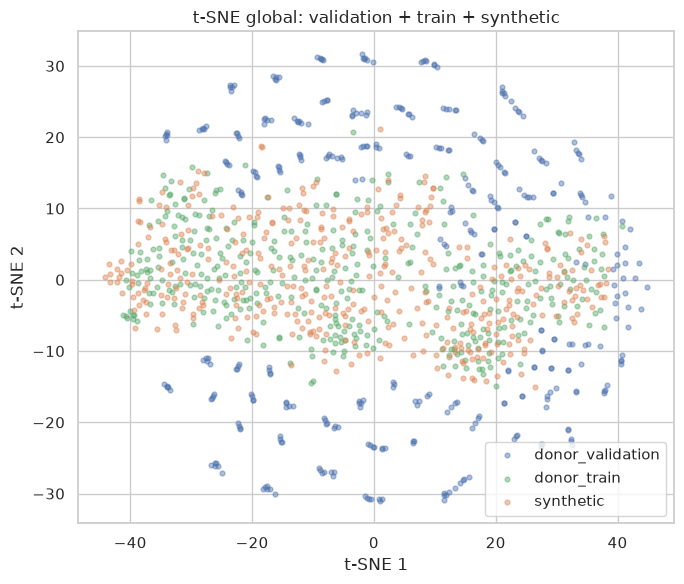

In [12]:
# Vista global: los tres grupos juntos
plt.figure(figsize=(7, 6))
for src, color in palette.items():
    m = embed_df["source"].eq(src)
    plt.scatter(embed_df.loc[m, "x"], embed_df.loc[m, "y"], s=12, alpha=0.45, label=src, c=color)
plt.legend()
plt.title("t-SNE global: validation + train + synthetic")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()

## 3. Clasificador — regresión logística (C2ST)

Etiqueta 0 = real, 1 = sintético. **AUC ≈ 0.5** → indistinguibles (bueno). **AUC → 1** → fácil detectar fakes (malo).

Tres comparaciones (pool agregado de las 3 seeds):

1. **`donor_validation` vs synthetic** — evaluación principal (reales ocultos del universo donor).
2. **`donor_train` vs synthetic** — sanity check (mismo dominio que entrenó la GAN).
3. **`nvda_hidden` vs synthetic** — exploratorio (NVDA 2012–2022 H1; no usar para tunear la GAN).

In [13]:
def run_classifier_two_sample_test(
    real_windows: np.ndarray,
    synthetic_windows: np.ndarray,
    *,
    real_label: str,
    cv_folds: int = 5,
    random_state: int = 42,
) -> dict:
    n = min(len(real_windows), len(synthetic_windows))
    rng = np.random.default_rng(random_state)
    real_idx = rng.choice(len(real_windows), size=n, replace=False)
    syn_idx = rng.choice(len(synthetic_windows), size=n, replace=False)

    X = np.vstack([
        real_windows[real_idx].reshape(n, -1),
        synthetic_windows[syn_idx].reshape(n, -1),
    ])
    y = np.array([0] * n + [1] * n)

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=2000, C=1.0, random_state=random_state)),
    ])

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    auc_scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")
    acc_scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=random_state
    )
    clf.fit(X_tr, y_tr)
    y_prob = clf.predict_proba(X_te)[:, 1]
    y_pred = clf.predict(X_te)

    return {
        "comparison": f"{real_label} (0) vs synthetic (1)",
        "n_per_class": n,
        "auc_cv_mean": float(auc_scores.mean()),
        "auc_cv_std": float(auc_scores.std()),
        "acc_cv_mean": float(acc_scores.mean()),
        "acc_cv_std": float(acc_scores.std()),
        "holdout_auc": float(roc_auc_score(y_te, y_prob)),
        "holdout_acc": float(accuracy_score(y_te, y_pred)),
        "holdout_report": classification_report(y_te, y_pred, target_names=["real", "synthetic"]),
        "fitted_model": clf,
        "X_test": X_te,
        "y_test": y_te,
        "y_prob": y_prob,
    }

In [14]:
CLASSIFIER_COMPARISONS = [
    ("donor_validation", X_val),
    ("donor_train", X_train),
    ("nvda_hidden", X_nvda_hidden),
]

classifier_results = {}
for real_label, X_real in CLASSIFIER_COMPARISONS:
    classifier_results[real_label] = run_classifier_two_sample_test(
        X_real, X_syn, real_label=real_label, cv_folds=CV_FOLDS
    )

result_val = classifier_results["donor_validation"]
result_train = classifier_results["donor_train"]
result_hidden = classifier_results["nvda_hidden"]

for result in classifier_results.values():
    print("=" * 60)
    print(result["comparison"])
    print(f"AUC CV : {result['auc_cv_mean']:.3f} ± {result['auc_cv_std']:.3f}")
    print(f"Acc CV : {result['acc_cv_mean']:.3f} ± {result['acc_cv_std']:.3f}")
    print(f"Holdout AUC: {result['holdout_auc']:.3f}  Acc: {result['holdout_acc']:.3f}")
    print(result["holdout_report"])

donor_validation (0) vs synthetic (1)
AUC CV : 0.913 ± 0.007
Acc CV : 0.851 ± 0.017
Holdout AUC: 0.889  Acc: 0.826
              precision    recall  f1-score   support

        real       0.82      0.83      0.83        95
   synthetic       0.83      0.82      0.83        95

    accuracy                           0.83       190
   macro avg       0.83      0.83      0.83       190
weighted avg       0.83      0.83      0.83       190

donor_train (0) vs synthetic (1)
AUC CV : 0.556 ± 0.012
Acc CV : 0.543 ± 0.010
Holdout AUC: 0.541  Acc: 0.532
              precision    recall  f1-score   support

        real       0.53      0.55      0.54      1228
   synthetic       0.53      0.51      0.52      1227

    accuracy                           0.53      2455
   macro avg       0.53      0.53      0.53      2455
weighted avg       0.53      0.53      0.53      2455



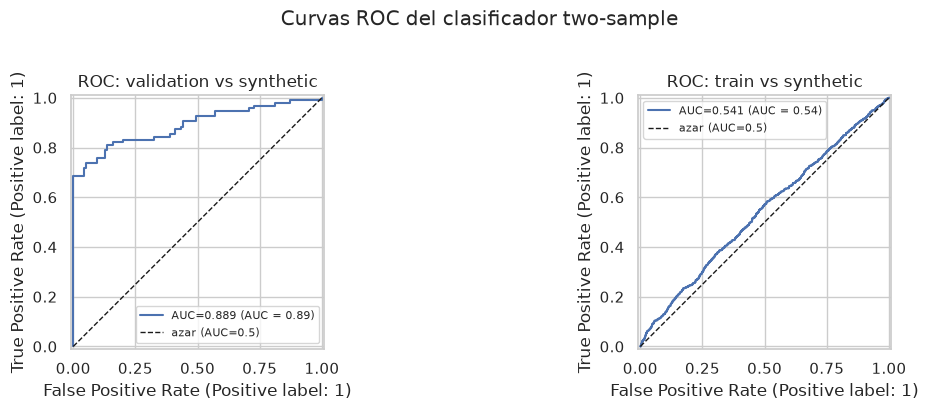

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (real_label, result) in zip(
    axes,
    [
        ("donor_validation", result_val),
        ("donor_train", result_train),
        ("nvda_hidden", result_hidden),
    ],
):
    RocCurveDisplay.from_predictions(
        result["y_test"],
        result["y_prob"],
        ax=ax,
        name=f"AUC={result['holdout_auc']:.3f}",
    )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="azar (AUC=0.5)")
    ax.set_title(f"ROC: {real_label} vs synthetic")
    ax.legend(fontsize=8)

plt.suptitle("Curvas ROC del clasificador two-sample", y=1.02)
plt.tight_layout()

### 3b. Clasificador por semilla

AUC por seed y comparación: valores más cercanos a **0.5** = mejor. Compara si alguna seed destaca en validation, train o NVDA hidden.

,seed,auc_cv_mean,auc_cv_std,acc_cv_mean
0,42,0.942521,0.016151,0.853947
1,123,0.924238,0.025493,0.871053
2,2026,0.920568,0.015247,0.848684


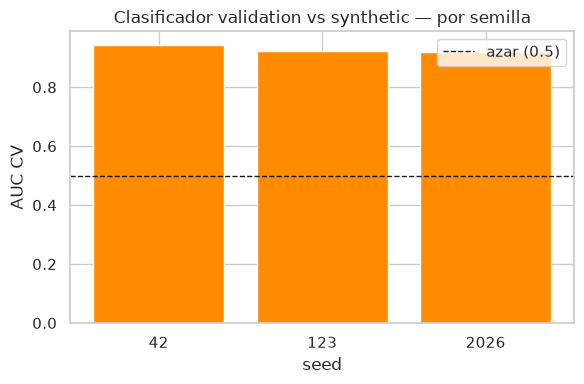

In [16]:
results_by_seed = []
for real_label, X_real in CLASSIFIER_COMPARISONS:
    for seed in sorted(X_syn_by_seed):
        result = run_classifier_two_sample_test(
            X_real,
            X_syn_by_seed[seed],
            real_label=f"{real_label} vs seed {seed}",
            cv_folds=CV_FOLDS,
            random_state=seed,
        )
        results_by_seed.append(
            {
                "comparison": real_label,
                "seed": seed,
                "auc_cv_mean": result["auc_cv_mean"],
                "auc_cv_std": result["auc_cv_std"],
                "acc_cv_mean": result["acc_cv_mean"],
            }
        )

per_seed_classifier = pd.DataFrame(results_by_seed).sort_values(["comparison", "seed"])
display(per_seed_classifier)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, real_label in zip(axes, [c[0] for c in CLASSIFIER_COMPARISONS]):
    subset = per_seed_classifier.loc[per_seed_classifier["comparison"].eq(real_label)]
    ax.bar(subset["seed"].astype(str), subset["auc_cv_mean"], color="darkorange")
    ax.axhline(0.5, color="k", linestyle="--", linewidth=1, label="azar (0.5)")
    ax.set_xlabel("seed")
    ax.set_ylabel("AUC CV")
    ax.set_title(f"{real_label} vs synthetic")
    ax.legend(fontsize=8)
plt.suptitle("Clasificador por semilla — tres comparaciones", y=1.02)
plt.tight_layout()

## Resumen ejecutivo

In [17]:
def quality_verdict(auc: float) -> str:
    dist = abs(auc - 0.5)
    if dist < 0.05:
        return "excelente (casi indistinguible)"
    if dist < 0.10:
        return "bueno"
    if dist < 0.20:
        return "moderado (hay señales detectables)"
    return "débil (fácil distinguir real vs sintético)"


exec_summary = pd.DataFrame([
    {
        "comparación": f"{real_label} vs synthetic (agregado 3 seeds)",
        "AUC_CV": classifier_results[real_label]["auc_cv_mean"],
        "veredicto": quality_verdict(classifier_results[real_label]["auc_cv_mean"]),
    }
    for real_label, _ in CLASSIFIER_COMPARISONS
])
display(exec_summary)

per_seed_summary = per_seed_classifier.copy()
per_seed_summary["veredicto_auc"] = per_seed_summary["auc_cv_mean"].map(quality_verdict)
per_seed_summary["delta_auc_from_random"] = (per_seed_summary["auc_cv_mean"] - 0.5).abs()

val_mmd = per_seed_mmd.set_index("seed")["mmd_flat"]
per_seed_summary.loc[per_seed_summary["comparison"].eq("donor_validation"), "mmd_flat"] = (
    per_seed_summary.loc[per_seed_summary["comparison"].eq("donor_validation"), "seed"].map(val_mmd)
)
display(per_seed_summary.sort_values(["comparison", "seed"]))

print("Seed con AUC más cercano a 0.5 en validation (mejor):")
best = (
    per_seed_summary.loc[per_seed_summary["comparison"].eq("donor_validation")]
    .sort_values("delta_auc_from_random")
    .iloc[0]
)
print(f"  seed {int(best['seed'])} — AUC={best['auc_cv_mean']:.3f}, MMD={best.get('mmd_flat', float('nan')):.4f}")

report_path = outputs_dir() / "synthetic_all_seeds.eval_generative.json"
payload = {
    "synthetic_paths": [str(path) for path in synthetic_paths],
    "n_synthetic_total": len(X_syn),
    "seeds": official_seeds(),
    "classifier_aggregated": {
        real_label: {
            k: v for k, v in classifier_results[real_label].items()
            if k not in {"fitted_model", "X_test", "y_test", "y_prob", "holdout_report"}
        }
        for real_label, _ in CLASSIFIER_COMPARISONS
    },
    "per_seed_mmd": per_seed_mmd.to_dict(orient="records"),
    "per_seed_classifier": per_seed_classifier.to_dict(orient="records"),
    "channel_summary": summary_table.to_dict(orient="records"),
    "autocorr_summary": autocorr_table.to_dict(orient="records"),
}
report_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print(f"Informe guardado en {report_path}")

,comparación,AUC_CV,veredicto
0,validation vs synthetic (agregado 3 seeds),0.912742,débil (fácil distinguir real vs sintético)
1,train vs synthetic (agregado 3 seeds),0.556129,bueno


,seed,auc_cv_mean,auc_cv_std,acc_cv_mean,mmd_flat,veredicto_auc,delta_auc_from_random
0,42,0.942521,0.016151,0.853947,0.022414,débil (fácil distinguir real vs sintético),0.442521
1,123,0.924238,0.025493,0.871053,0.014741,débil (fácil distinguir real vs sintético),0.424238
2,2026,0.920568,0.015247,0.848684,0.009423,débil (fácil distinguir real vs sintético),0.420568


Seed con AUC más cercano a 0.5 (mejor):
  seed 2026 — AUC=0.921, MMD=0.0094
Informe guardado en /home/cristian/Documents/miax/modulo5/2026_Modelos_generativos/taller/taller_cristian/generadores/cristian/outputs/synthetic_all_seeds.eval_generative.json
